# Tratamento dos textos pra extração de features

In [55]:
import math
import re
import numpy as np
import pandas as pd
from collections import Counter
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from spellchecker import SpellChecker
from nltk.corpus import stopwords

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger') 

class TextFeatureExtractor:
    def __init__(self, max_vocab=1500):
        self.max_vocab = max_vocab
        self.spell = SpellChecker()
        self.vocab = None
        self.idf = None
        self.stopwords = set(stopwords.words("english"))
        self.LLM_BUZZWORDS = {
            'furthermore','moreover','delve','tapestry',
            'testament','pivotal','underscore','multifaceted',
            'crucial','consequently'
        }

    def _get_metrics(self, text):
    
        sentences = sent_tokenize(text)
        raw_tokens = word_tokenize(text)
        words = [w.lower() for w in raw_tokens if w.isalpha()]
    
        if not words:
            return [0]*16
    
        # ---------- BASIC FEATURES ----------
    
        s_lengths = [len(word_tokenize(s)) for s in sentences]
        burst = np.std(s_lengths) if len(sentences) > 1 else 0
    
        typos = len(self.spell.unknown(words)) / len(words)
    
        counts = Counter(words)
        total = len(words)
    
        ent = sum(-(c/total)*math.log2(c/total) for c in counts.values())
    
        ttr_val = len(set(words))/len(words)
    
        awl = np.mean([len(w) for w in words])
    
        asl = len(words)/len(sentences) if sentences else 0
    
        buzz = sum(w in self.LLM_BUZZWORDS for w in words)/len(words)
    
        tags = nltk.pos_tag(raw_tokens)
        adj = sum(tag.startswith('JJ') for _,tag in tags)/len(raw_tokens) if raw_tokens else 0
    
        punct = (text.count('!') + text.count('?') + text.count('...')) / len(text) if text else 0
    
    
        # ---------- NGRAM FEATURES ----------
    
        bigrams = list(zip(words, words[1:]))
        unique_bigrams = len(set(bigrams))
        bigram_ratio = unique_bigrams / len(bigrams) if bigrams else 0
    
        text_clean = text.replace(" ", "_")
        char_trigrams = [text_clean[i:i+3] for i in range(len(text_clean)-2)]
        char_trigram_density = len(set(char_trigrams)) / len(char_trigrams) if char_trigrams else 0
    
    
        # ---------- PERPLEXITY (BIGRAM LM APPROX) ----------
    
        unigram_counts = Counter(words)
        bigram_counts = Counter(bigrams)
    
        log_prob_sum = 0
        N = len(bigrams)
    
        for w1, w2 in bigrams:
        
            p = (bigram_counts[(w1,w2)] + 1) / (unigram_counts[w1] + len(unigram_counts))
            log_prob_sum += math.log2(p)
    
        perplexity = 2 ** (-log_prob_sum / N) if N > 0 else 0
    
    
        # ---------- POS FEATURES ----------
    
        pos_tags = [tag for _,tag in tags]
        pos_counts = Counter(pos_tags)
    
        pos_total = len(pos_tags)
        pos_entropy = sum(-(c/pos_total)*math.log2(c/pos_total) for c in pos_counts.values())
    
    
        # ---------- RHYTHM FEATURES ----------
    
        sent_lengths = [len(word_tokenize(s)) for s in sentences]
        rhythm_var = np.var(sent_lengths) if len(sent_lengths) > 1 else 0
    
    
        # ---------- STOPWORD FEATURES ----------
    
        stop_ratio = sum(w in self.stopwords for w in words)/len(words)
    
    
        # ---------- RARE WORD RATIO ----------
    
        rare_words = [w for w,c in counts.items() if c == 1]
        rare_ratio = len(rare_words)/len(words)
    
    
        return [
            burst,
            typos,
            ent,
            ttr_val,
            awl,
            asl,
            buzz,
            adj,
            punct,
    
            bigram_ratio,
            char_trigram_density,
            perplexity,
            pos_entropy,
            rhythm_var,
            stop_ratio,
            rare_ratio
        ]

    def fit_tfidf(self, corpus):
        tokenized = [re.findall(r'\b[a-zA-Z]+\b', doc.lower()) for doc in corpus]
        doc_freq = Counter()
        for doc in tokenized:
            for word in set(doc):
                doc_freq[word] += 1
        self.vocab = [w for w, _ in doc_freq.most_common(self.max_vocab)]
        N = len(corpus)
        self.idf = {w: math.log((1+N)/(1+doc_freq[w])) + 1 for w in self.vocab}

    def transform_tfidf(self, corpus):
        matrix = []
        for doc in corpus:
            words = re.findall(r'\b[a-zA-Z]+\b', doc.lower())
            tf = Counter(words)
            length = len(words) if words else 1
            row = [(tf.get(w, 0)/length) * self.idf[w] for w in self.vocab]
            matrix.append(row)
        return np.array(matrix)

    def fit_transform(self, corpus):
        corpus = [str(t) for t in corpus]
        
        # Fit and Transform TF-IDF
        self.fit_tfidf(corpus)
        tfidf_matrix = self.transform_tfidf(corpus)
        
        # Transform Behavioral
        behavioral_matrix = np.array([self._get_metrics(t) for t in corpus])
        
        # Return as separate entities
        return tfidf_matrix, behavioral_matrix
    
#df = pd.read_csv("../data/raw/dataset-exemplos.csv", sep=";").dropna()
df = pd.read_csv("../data/dataset.csv").dropna()

# 1. Extração de Features
extractor = TextFeatureExtractor(max_vocab=1500)
X_tfidf, X_extra = extractor.fit_transform(df["text"])

# Normalização das métricas comportamentais
min_vals = np.min(X_extra, axis=0)
max_vals = np.max(X_extra, axis=0)
X_extra_norm = (X_extra - min_vals) / (max_vals - min_vals + 1e-8)

# Concatenar (512 TF-IDF + 16 métricas = 528 inputs)
X_combined = np.hstack((X_tfidf, X_extra_norm))

# One-Hot Encoding das Labels
labels_list = df['label'].unique()
label_to_idx = {l: i for i, l in enumerate(labels_list)}
Y_indices = np.array([label_to_idx[l] for l in df['label']])
Y_onehot = np.zeros((len(Y_indices), len(labels_list)))
Y_onehot[np.arange(len(Y_indices)), Y_indices] = 1

# Split (70% Treino, 10% Validação, 20% Teste)
np.random.seed(42)
shuffled_idx = np.arange(len(X_combined))
np.random.shuffle(shuffled_idx)

X_s, Y_s = X_combined[shuffled_idx], Y_onehot[shuffled_idx]

train_end = int(len(X_s) * 0.7)
val_end = int(len(X_s) * 0.8)

X_train, Y_train = X_s[:train_end], Y_s[:train_end]
X_val, Y_val     = X_s[train_end:val_end], Y_s[train_end:val_end]
X_test, Y_test   = X_s[val_end:], Y_s[val_end:]

print(f"Dataset processado: {X_train.shape[0]} treino, {X_val.shape[0]} validação, {X_test.shape[0]} teste.")
print(f"Dimensão final do input: {X_train.shape[1]}")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mjurb\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mjurb\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\mjurb\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Dataset processado: 1722 treino, 246 validação, 492 teste.
Dimensão final do input: 1516


# Numpy


--- Iniciando Treino Final com Monitorização ---


Epoch 10/200 | Train Loss: 1.5341 | Val Loss: 1.5273
Epoch 20/200 | Train Loss: 1.4253 | Val Loss: 1.4519
Epoch 30/200 | Train Loss: 1.3464 | Val Loss: 1.3950
Epoch 40/200 | Train Loss: 1.2849 | Val Loss: 1.3509
Epoch 50/200 | Train Loss: 1.2384 | Val Loss: 1.3029
Epoch 60/200 | Train Loss: 1.1913 | Val Loss: 1.2948
Epoch 70/200 | Train Loss: 1.1440 | Val Loss: 1.2698
Epoch 80/200 | Train Loss: 1.1070 | Val Loss: 1.2330
Epoch 90/200 | Train Loss: 1.0629 | Val Loss: 1.2343
Epoch 100/200 | Train Loss: 1.0179 | Val Loss: 1.1818
Epoch 110/200 | Train Loss: 0.9667 | Val Loss: 1.1632
Epoch 120/200 | Train Loss: 0.9243 | Val Loss: 1.1550
Epoch 130/200 | Train Loss: 0.8769 | Val Loss: 1.1248
Epoch 140/200 | Train Loss: 0.8529 | Val Loss: 1.1095
Epoch 150/200 | Train Loss: 0.8073 | Val Loss: 1.1422
Epoch 160/200 | Train Loss: 0.7786 | Val Loss: 1.1338
Epoch 170/200 | Train Loss: 0.7358 | Val Loss: 1.0885
Epoch 180/200 | Train Loss: 0.6677 | Val Loss: 1.0708
Epoch 190/200 | Train Loss: 0.6601 | 

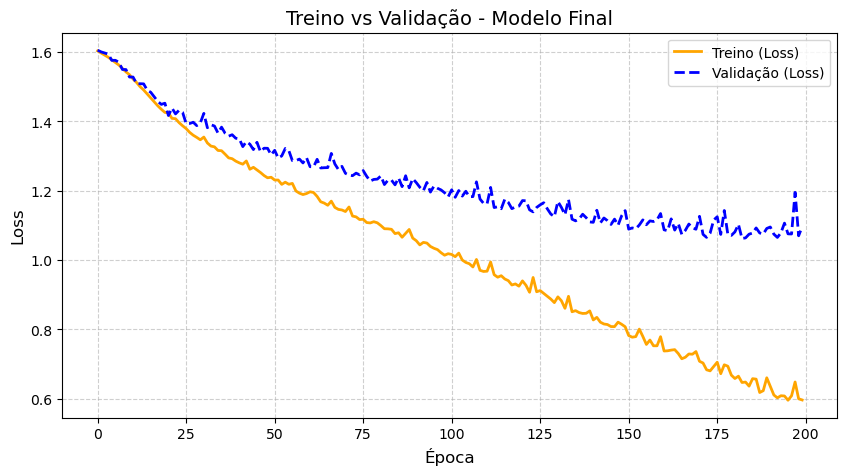


--- Avaliação Final (Conjunto de Teste) ---
Teste Accuracy: 56.10%


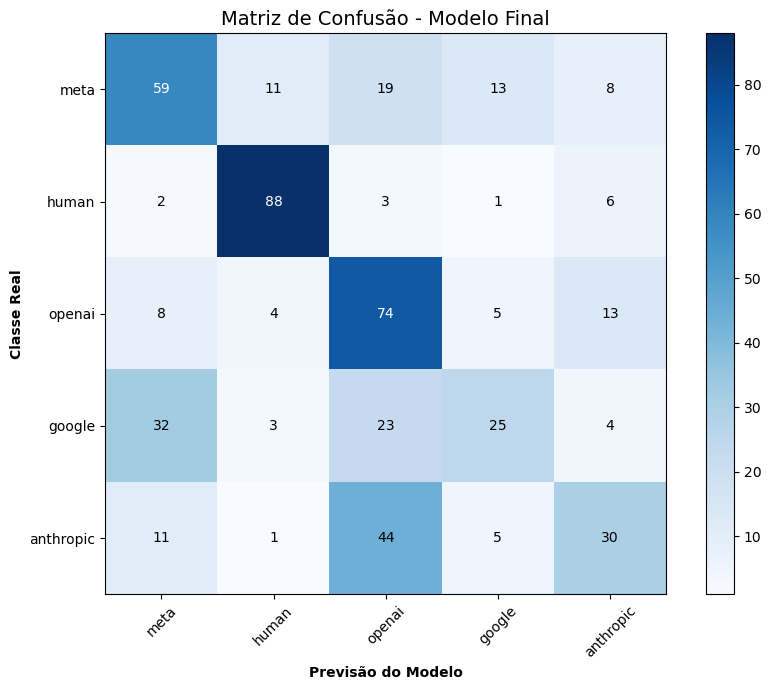

In [56]:
import sys
import os
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('../src'))
from neuralnet import NeuralNetwork
from layers import DenseLayer
from activations import ReLUActivation, SoftmaxActivation
from losses import CategoricalCrossEntropy

# 1. Recriar a rede com a arquitetura simplificada (vencedora)
numpy_model = NeuralNetwork(loss_func=CategoricalCrossEntropy())
lr, mom = 0.005, 0.9 

# Apenas UMA camada oculta
numpy_model.add(DenseLayer(X_train.shape[1], 64, lr, mom))
numpy_model.add(ReLUActivation())
numpy_model.add(DenseLayer(64, len(labels_list), lr, mom))
numpy_model.add(SoftmaxActivation())

print("\n--- Iniciando Treino Final com Monitorização ---")
epochs = 200
batch_size = 32

history_train_loss = []
history_val_loss = []

# 2. Treinar 1 época de cada vez para podermos capturar e plotar a Validação
for epoch in range(epochs):
    # Treina apenas 1 época (verbose=False para o print ficar mais limpo)
    numpy_model.fit(X_train, Y_train, epochs=1, batch_size=batch_size, verbose=False)
    
    # Captura as perdas
    train_loss = numpy_model.history['loss'][-1]
    history_train_loss.append(train_loss)
    
    val_loss, val_accuracy = numpy_model.evaluate(X_val, Y_val)
    history_val_loss.append(val_loss)
    
    # Faz print a cada 10 épocas e na última
    if (epoch + 1) % 10 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch + 1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# 3. Plot das Duas Curvas (Treino vs Validação)
plt.figure(figsize=(10, 5))
plt.plot(history_train_loss, label='Treino (Loss)', color='orange', linewidth=2)
plt.plot(history_val_loss, label='Validação (Loss)', color='blue', linewidth=2, linestyle='--')
plt.title('Treino vs Validação - Modelo Final', fontsize=14)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# 4. Avaliação no Conjunto de Teste (A verdadeira prova dos 9)
y_pred_proba = numpy_model.forward_propagation(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(Y_test, axis=1)

accuracy = np.mean(y_pred == y_true) * 100
print(f"\n--- Avaliação Final (Conjunto de Teste) ---")
print(f"Teste Accuracy: {accuracy:.2f}%")

# 5. Matriz de Confusão
cm = np.zeros((len(labels_list), len(labels_list)), dtype=int)
for t, p in zip(y_true, y_pred):
    cm[t, p] += 1

plt.figure(figsize=(9, 7))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Matriz de Confusão - Modelo Final', fontsize=14)
plt.colorbar()

tick_marks = np.arange(len(labels_list))
plt.xticks(tick_marks, labels_list, rotation=45)
plt.yticks(tick_marks, labels_list)

thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
             color="white" if cm[i, j] > thresh else "black")

plt.xlabel('Previsão do Modelo', fontweight='bold')
plt.ylabel('Classe Real', fontweight='bold')
plt.tight_layout()
plt.show()

# Pytorch

A usar dispositivo: cuda

--- Treino PyTorch Iniciado ---


Epoch 10/200 | Train Loss: 1.2429 | Val Loss: 1.2629
Epoch 20/200 | Train Loss: 0.8525 | Val Loss: 1.1831
Epoch 30/200 | Train Loss: 0.7650 | Val Loss: 1.2477
Epoch 40/200 | Train Loss: 0.6778 | Val Loss: 1.3627
Epoch 50/200 | Train Loss: 0.5875 | Val Loss: 1.4525
Epoch 60/200 | Train Loss: 0.5017 | Val Loss: 1.6572
Epoch 70/200 | Train Loss: 0.4680 | Val Loss: 1.6589
Epoch 80/200 | Train Loss: 0.3986 | Val Loss: 2.0616
Epoch 90/200 | Train Loss: 0.3470 | Val Loss: 1.9645
Epoch 100/200 | Train Loss: 0.2685 | Val Loss: 1.9668
Epoch 110/200 | Train Loss: 0.2037 | Val Loss: 2.0629
Epoch 120/200 | Train Loss: 0.2254 | Val Loss: 2.0915
Epoch 130/200 | Train Loss: 0.1787 | Val Loss: 2.1137
Epoch 140/200 | Train Loss: 0.1886 | Val Loss: 2.0854
Epoch 150/200 | Train Loss: 0.1900 | Val Loss: 2.0052
Epoch 160/200 | Train Loss: 0.1691 | Val Loss: 2.0523
Epoch 170/200 | Train Loss: 0.1791 | Val Loss: 2.0069
Epoch 180/200 | Train Loss: 0.1652 | Val Loss: 2.1113
Epoch 190/200 | Train Loss: 0.1441 | 

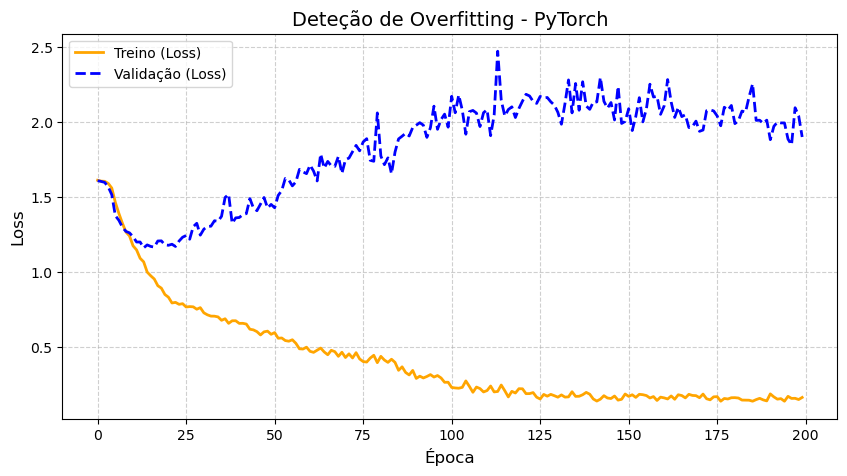


PyTorch Accuracy (Conjunto de Teste): 55.49%


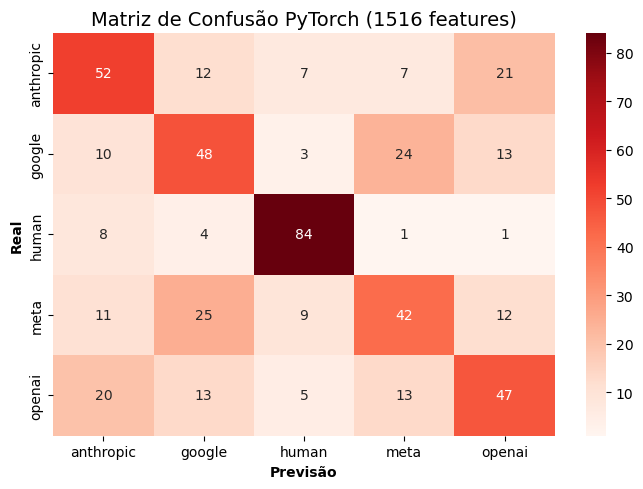

In [83]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"A usar dispositivo: {device}")

# 1. Preparação Sklearn
scaler = MinMaxScaler()
# Nota: Assumindo que X_extra e X_tfidf vêm do teu passo de extração anterior
X_extra_scaled = scaler.fit_transform(X_extra)
X_combined_pt = np.hstack((X_tfidf, X_extra_scaled))

encoder = LabelEncoder()
y_pt = encoder.fit_transform(df['label'])

# --- DIVISÃO COM VALIDAÇÃO (70% Treino, 10% Validação, 20% Teste) ---
# Primeiro: separar os 20% de Teste
X_temp, X_test, y_temp, y_test = train_test_split(X_combined_pt, y_pt, test_size=0.2, stratify=y_pt, random_state=42)
# Segundo: dos 80% restantes, tirar 12.5% para Validação (o que equivale a 10% do total)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.125, stratify=y_temp, random_state=42)

# 2. Tensores e Loaders
train_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_train).to(device), torch.LongTensor(y_train).to(device)), 
    batch_size=32, 
    shuffle=True
)

X_val_t = torch.FloatTensor(X_val).to(device)
y_val_t = torch.LongTensor(y_val).to(device)

X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.LongTensor(y_test).to(device)

# 3. Modelo PyTorch
class DetectorIADeep(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            
            nn.Linear(input_size, 512), 
            nn.ReLU(), 
            nn.Dropout(0.5), # Aumentamos o Dropout para 50%
            nn.Linear(512, 128),
            nn.ReLU(), 
            nn.Dropout(0.5),
            nn.Linear(128, 32), 
            nn.ReLU(), 
            nn.Dropout(0.5), # Aumentamos o Dropout para 50%
            nn.Linear(32, num_classes)
        )
    def forward(self, x): 
        return self.net(x)

model = DetectorIADeep(X_train.shape[1], len(encoder.classes_)).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)
criterion = nn.CrossEntropyLoss()

# 4. Treino com Captura de Validação
print("\n--- Treino PyTorch Iniciado ---")
epochs = 200
train_losses = []
val_losses = []

for epoch in range(epochs):
    # Modo de Treino (ativa Dropout)
    model.train()
    batch_losses = []
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
        
    # Média da loss do treino para esta época
    epoch_train_loss = np.mean(batch_losses)
    train_losses.append(epoch_train_loss)
    
    # Modo de Avaliação (desativa Dropout para a validação)
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_t)
        val_loss = criterion(val_outputs, y_val_t)
        val_losses.append(val_loss.item())
        
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {val_loss.item():.4f}")

# 5. Plot das Curvas de Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Treino (Loss)', color='orange', linewidth=2)
plt.plot(val_losses, label='Validação (Loss)', color='blue', linewidth=2, linestyle='--')
plt.title('Deteção de Overfitting - PyTorch', fontsize=14)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# 6. Accuracy e Matriz Seaborn no Conjunto de Teste
model.eval() # Garantir que o modelo continua em modo avaliação
with torch.no_grad():
    outputs = model(X_test_t)
    _, predicted = torch.max(outputs, 1)
    acc = 100 * (predicted == y_test_t).sum().item() / y_test_t.size(0)

print(f"\nPyTorch Accuracy (Conjunto de Teste): {acc:.2f}%")

cm_pt = confusion_matrix(y_test_t.cpu(), predicted.cpu())
plt.figure(figsize=(7, 5))
sns.heatmap(cm_pt, annot=True, fmt='d', cmap='Reds', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title(f'Matriz de Confusão PyTorch ({X_train.shape[1]} features)', fontsize=14)
plt.xlabel('Previsão', fontweight='bold')
plt.ylabel('Real', fontweight='bold')
plt.tight_layout()
plt.show()

# Teste

Novo dataset carregado com 125 amostras.
Labels corrigidas para coincidir com o treino: ['human' 'meta' 'google' 'openai' 'anthropic']
A extrair features do novo dataset...

--- A avaliar Modelo NumPy ---
NumPy Accuracy (Novo Dataset): 27.20%

--- A avaliar Modelo PyTorch ---
PyTorch Accuracy (Novo Dataset): 52.80%


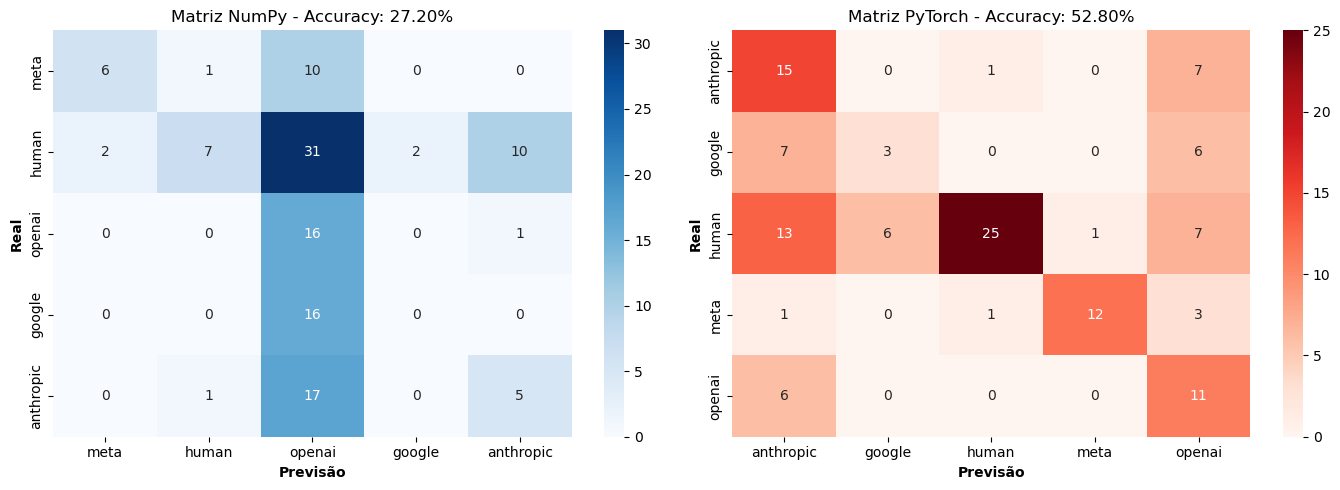

In [84]:
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Carregar o Novo Dataset
caminho_novo_dataset = "../data/raw/dataset-exemplos.csv" 
df_new = pd.read_csv(caminho_novo_dataset, sep=";").dropna()

print(f"Novo dataset carregado com {len(df_new)} amostras.")

# --- CORREÇÃO DAS LABELS ---
# Vamos descobrir como as labels originais estavam escritas
classes_originais = list(label_to_idx.keys())

# Criar um dicionário que mapeia a versão minúscula para a versão exata do treino
# Exemplo: {'human': 'human', 'ai': 'ai'} ou {'human': 'Human'} dependendo do treino
mapa_classes = {str(c).lower(): c for c in classes_originais}

# Aplicar a correção à nova coluna: passa para minúscula e vai buscar o formato correto
df_new['Label'] = df_new['Label'].apply(lambda x: mapa_classes.get(str(x).lower(), x))

print(f"Labels corrigidas para coincidir com o treino: {df_new['Label'].unique()}")

# 2. Extração de Features (Apenas TRANSFORM, nunca FIT!)
print("A extrair features do novo dataset...")
corpus_new = [str(t) for t in df_new["Text"]]

# Usamos o teu 'extractor' que já foi fittado no treino
X_tfidf_new = extractor.transform_tfidf(corpus_new)
X_extra_new = np.array([extractor._get_metrics(t) for t in corpus_new])

# ==========================================
# TESTE 1: MODELO NUMPY (Feito do Zero)
# ==========================================
print("\n--- A avaliar Modelo NumPy ---")

# Normalizar com os min/max guardados do treino
X_extra_norm_new = (X_extra_new - min_vals) / (max_vals - min_vals + 1e-8)
X_combined_np_new = np.hstack((X_tfidf_new, X_extra_norm_new))

# Converter labels novas para índices usando o dicionário antigo
# Nota: Assumindo que as labels no novo dataset coincidem com as do antigo (ex: 'Human', 'AI')
y_true_np_new = np.array([label_to_idx[l] for l in df_new['Label']])

# Fazer previsões
y_pred_proba_np = numpy_model.forward_propagation(X_combined_np_new)
y_pred_np_new = np.argmax(y_pred_proba_np, axis=1)

# Accuracy NumPy
acc_np = np.mean(y_pred_np_new == y_true_np_new) * 100
print(f"NumPy Accuracy (Novo Dataset): {acc_np:.2f}%")

# ==========================================
# TESTE 2: MODELO PYTORCH
# ==========================================
print("\n--- A avaliar Modelo PyTorch ---")

# Normalizar com o Scaler do Sklearn guardado do treino
X_extra_scaled_new = scaler.transform(X_extra_new)
X_combined_pt_new = np.hstack((X_tfidf_new, X_extra_scaled_new))

# Converter features para Tensores
X_new_t = torch.FloatTensor(X_combined_pt_new).to(device)

# Converter labels com o Encoder do treino
y_pt_new = encoder.transform(df_new['Label'])
y_new_t = torch.LongTensor(y_pt_new).to(device)

# Fazer previsões
model.eval() # Garantir que o modelo está em modo avaliação (sem Dropout)
with torch.no_grad():
    outputs_new = model(X_new_t)
    _, predicted_pt_new = torch.max(outputs_new, 1)
    
acc_pt = 100 * (predicted_pt_new == y_new_t).sum().item() / y_new_t.size(0)
print(f"PyTorch Accuracy (Novo Dataset): {acc_pt:.2f}%")

# ==========================================
# PLOT DAS DUAS MATRIZES DE CONFUSÃO
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz NumPy
cm_np = confusion_matrix(y_true_np_new, y_pred_np_new)
sns.heatmap(cm_np, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels_list, yticklabels=labels_list, ax=axes[0])
axes[0].set_title(f'Matriz NumPy - Accuracy: {acc_np:.2f}%', fontsize=12)
axes[0].set_xlabel('Previsão', fontweight='bold')
axes[0].set_ylabel('Real', fontweight='bold')

# Matriz PyTorch
cm_pt = confusion_matrix(y_pt_new, predicted_pt_new.cpu())
sns.heatmap(cm_pt, annot=True, fmt='d', cmap='Reds', 
            xticklabels=encoder.classes_, yticklabels=encoder.classes_, ax=axes[1])
axes[1].set_title(f'Matriz PyTorch - Accuracy: {acc_pt:.2f}%', fontsize=12)
axes[1].set_xlabel('Previsão', fontweight='bold')
axes[1].set_ylabel('Real', fontweight='bold')

plt.tight_layout()
plt.show()